# Modélisation_RL
## Régression Logistique Multinomiale

**Objectif :** Point de référence solide explicable

statsmodels fournit des p-values, pour valider la significativité stat de nos variables

**Problématiques traitées :**
1.  **Nature des variables :** Transformation des cotes en probas implicites pour linéariser la relation
2.  **Multicollinéarité :** Sélection des variables pour éviter la redondance
3.  **Biais des nuls :** matrice de confusion pour voir timidité des nuls

### Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, log_loss, brier_score_loss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore") 
sns.set_theme(style="whitegrid")

# constantes du projet
TARGET_COL = "FTResult"
TARGET_MAPPER = {'H': 0, 'D': 1, 'A': 2}
CLASSES = [0, 1, 2]
CLASS_LABELS = ["Home (0)", "Draw (1)", "Away (2)"]

# Chemin vers les données (A GENERALISER POUR SIMON)
PATH_DATA = "C:/Users/Alban/Documents/IMDS/Projet_5A/Donnees/matches_select_championnats.csv"

### Chargement et Feature Engineering

1.  **Nettoyage des cotes :** Les cotes à 0 sont traitées comme NaN pour éviter les erreurs de division
2.  **Linéarisation :** Transformation des Cotes en `Probabilités Implicites` (1/Cote)
3.  **Sélection de variables :** On exclut certaines variables (ex: `ImpProb_Away`) de l'entraînement pour éviter la **collinéarité parfaite** (somme des probas = 1), qui ferait planter l'estimation des coefficient

In [2]:
def load_and_select_features(path):
    """
    Charge les données, nettoie les cotes à 0, crée les probas implicites.
    Retourne df complet et features.
    """
    try:
        df = pd.read_csv(path, sep=";", parse_dates=["MatchDate"], dayfirst=True)
    except:
        df = pd.read_csv(path, sep=",", parse_dates=["MatchDate"], dayfirst=True)
    
    if TARGET_COL in df.columns:
        df = df[df[TARGET_COL].isin(["H", "D", "A"])]
        df["target"] = df[TARGET_COL].map(TARGET_MAPPER)
    
    # Sélection des variables brutes potentielles
    keep_features = ["EloDiff", "Form5Diff", "OddHome", "OddDraw", "OddAway", "Season"]
    available_features = [c for c in keep_features if c in df.columns]
    
    # Nettoyage initial des NaN sur ces colonnes
    df_clean = df.dropna(subset=available_features + ["target"]).reset_index(drop=True)
    
    # Feature Engineering et Nettoyage des Zéros
    if "OddHome" in df_clean.columns:
        cols_odds = [c for c in ["OddHome", "OddDraw", "OddAway"] if c in df_clean.columns]
        df_clean[cols_odds] = df_clean[cols_odds].replace(0, np.nan)
        
        # Calcul des inverses
        df_clean["ImpProb_Home"] = 1 / df_clean["OddHome"]
        df_clean["ImpProb_Draw"] = 1 / df_clean["OddDraw"]
        if "OddAway" in df_clean.columns:
            df_clean["ImpProb_Away"] = 1 / df_clean["OddAway"]
        
        # Liste des features POUR LE MODÈLE
        final_features = ["EloDiff", "Form5Diff", "ImpProb_Home", "ImpProb_Draw"] 
    else:
        final_features = available_features

    # Nettoyage FINAL 
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    cols_to_check = final_features + ["target"]
    if "ImpProb_Away" in df_clean.columns:
        cols_to_check.append("ImpProb_Away")
        
    df_clean = df_clean.dropna(subset=cols_to_check).reset_index(drop=True)

    return df_clean, final_features

# Exécution
df_model, features_model = load_and_select_features(PATH_DATA)
print(f"Données : {df_model.shape}")
print(f"Variables explicatives : {features_model}")

Données : (47369, 52)
Variables explicatives : ['EloDiff', 'Form5Diff', 'ImpProb_Home', 'ImpProb_Draw']


Split 1 :

Train : 25% des données (le plus vieux)
Test : 25% des données (bloc suivant)

Split 2 :

Train : 50% des données (Tout Split 1)
Test : 25% des données (bloc suivant)

Split 3 :

Train : 75% des données (Tout Split 2)
Test : 25% des données (bloc suivant)

-> essayer d'autres splits temporels

### Fonctions d'Évaluation

In [3]:
def make_time_splits(df, date_col="MatchDate", n_splits=3):
    """Divise le dataset temporellement sans fuite"""
    df = df.sort_values(date_col)
    n = len(df)
    fold_size = n // (n_splits + 1)
    splits = []
    
    for i in range(n_splits):
        train_end = fold_size * (i + 1)
        val_end = train_end + fold_size
        if i == n_splits - 1: val_end = n
        splits.append((df.index[:train_end], df.index[train_end:val_end]))
        
    return splits

def plot_confusion_matrix(y_true, y_pred, title="Matrice de Confusion"):
    """Affiche une matrice de confusion normalisée et brute"""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Valeurs brutes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    ax[0].set_title(f"{title} (Volume)")
    ax[0].set_ylabel('Réalité')
    ax[0].set_xlabel('Prédiction')
    
    # Valeurs normalisées (%)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=ax[1],
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    ax[1].set_title(f"{title} (Normalisée)")
    ax[1].set_ylabel('Réalité')
    ax[1].set_xlabel('Prédiction')
    
    plt.tight_layout()
    plt.show()
    
def display_advanced_diagnostics(model_result, y_true, y_pred, feature_names):
    """Affiche interprétation des coeffs et la matrice"""
    
    print("DIAGNOSTIC FINAL (Dernier Fold)")
    
    # 1. Matrice
    plot_confusion_matrix(y_true, y_pred, title="Matrice de Confusion")
    
    try:
        print(model_result.summary())
    except:
        print("Matrice de covariance non calculable")
        print("Coeff bruts :")
        print(model_result.params)

### Entraînement et Analyse


FOLD 1/3 (Train: 11842 | Val: 11842)
-> Accuracy Modèle : 0.5209
-> Accuracy Côte : 0.5231 (Diff: -0.0021)
-> Log Loss        : 0.9835

FOLD 2/3 (Train: 23684 | Val: 11842)
-> Accuracy Modèle : 0.5120
-> Accuracy Côte : 0.5123 (Diff: -0.0003)
-> Log Loss        : 0.9907

FOLD 3/3 (Train: 35526 | Val: 11843)
-> Accuracy Modèle : 0.5249
-> Accuracy Côte : 0.5256 (Diff: -0.0008)
-> Log Loss        : 0.9806
DIAGNOSTIC FINAL (Dernier Fold)


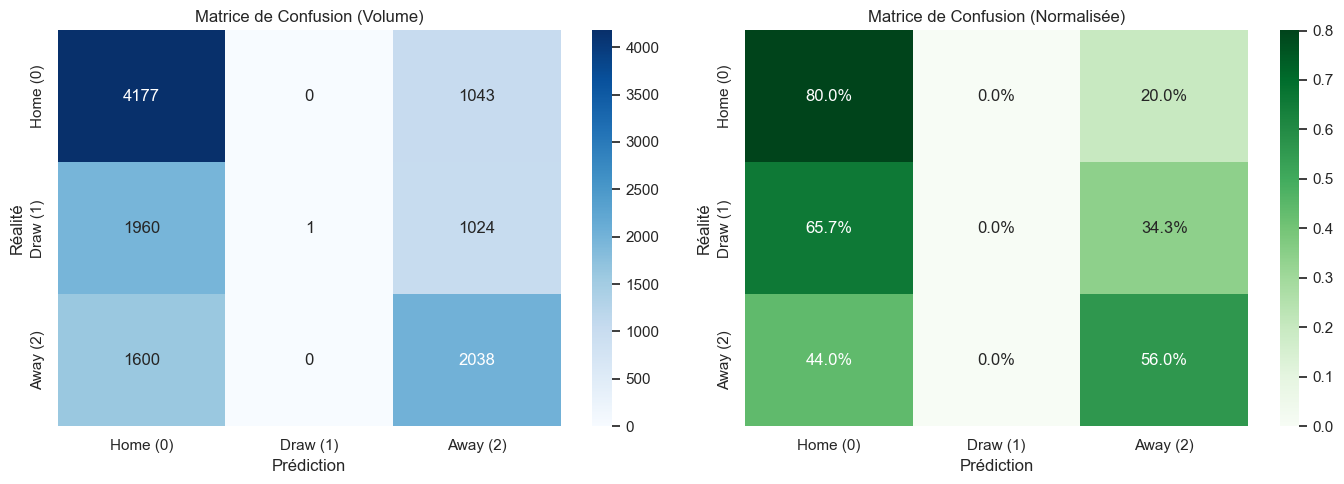

                          MNLogit Regression Results                          
Dep. Variable:                 target   No. Observations:                35526
Model:                        MNLogit   Df Residuals:                    35516
Method:                           MLE   Df Model:                            8
Date:                Fri, 28 Nov 2025   Pseudo R-squ.:                 0.07270
Time:                        08:38:30   Log-Likelihood:                -35234.
converged:                       True   LL-Null:                       -37996.
Covariance Type:            nonrobust   LLR p-value:                     0.000
    target=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4817      0.014    -35.136      0.000      -0.509      -0.455
EloDiff         -0.0653      0.033     -1.990      0.047      -0.130      -0.001
Form5Diff        0.0329      0.017      1.99

In [4]:
def run_rigorous_logistic_regression(df, features, target_col="target", n_splits=3):
    """
    Boucle d'entraînement avec validation temporelle.
    Compare le modèle aux côtes
    """
    # Tri temporel
    df = df.sort_values("MatchDate").reset_index(drop=True)
    splits = make_time_splits(df, n_splits=n_splits)
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"\nFOLD {fold+1}/{n_splits} (Train: {len(train_idx)} | Val: {len(val_idx)})")
        
        # Préparation X/y
        X_train = df.loc[train_idx, features]
        y_train = df.loc[train_idx, target_col]
        X_val = df.loc[val_idx, features]
        y_val = df.loc[val_idx, target_col]
        
        # Standardisation (Z-Score)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        # Conversion DF + Constante (Intercept)
        X_train_sm = sm.add_constant(pd.DataFrame(X_train_scaled, columns=features, index=X_train.index))
        X_val_sm = sm.add_constant(pd.DataFrame(X_val_scaled, columns=features, index=X_val.index))
        
        try:
            # Entraînement MNLogit
            model = sm.MNLogit(y_train, X_train_sm)
            result = model.fit(method='lbfgs', maxiter=1000, disp=0) 
            
            # Prédictions
            y_prob = result.predict(X_val_sm)
            y_pred = np.argmax(y_prob.values, axis=1)
            
            # Métriques Modèle
            acc = accuracy_score(y_val, y_pred)
            ll = log_loss(y_val, y_prob)
            
            # Métriques Marché 
            if "ImpProb_Home" in df.columns and "ImpProb_Away" in df.columns:
                market_cols = ["ImpProb_Home", "ImpProb_Draw", "ImpProb_Away"]
                market_pred = df.loc[val_idx, market_cols].idxmax(axis=1).map({
                    "ImpProb_Home": 0, "ImpProb_Draw": 1, "ImpProb_Away": 2
                })
                baseline_acc = accuracy_score(y_val, market_pred)
                print(f"-> Accuracy Modèle : {acc:.4f}")
                print(f"-> Accuracy Côte : {baseline_acc:.4f} (Diff: {acc - baseline_acc:+.4f})")
            else:
                print(f"-> Accuracy Modèle : {acc:.4f}")
            
            print(f"-> Log Loss        : {ll:.4f}")
            
            if fold == n_splits - 1:
                display_advanced_diagnostics(result, y_val, y_pred, features)

        except Exception as e:
            print(f"Erreur sur le fold {fold+1}: {e}")

# lancement
run_rigorous_logistic_regression(df_model, features_model, n_splits=3)

### 10% de test 


Split 1 : Train = 0%->70% Test = 70%->80%  
0.5144 - 0.5169 (Diff: -0.0025)

Split 2 : Train = 0%->80% Test = 80%->90%
0.5336 - 0.5338 (Diff: -0.0002)

Split 3 : Train = 0%->90% Test = 90%->100%
0.5198 - 0.5201 (Diff: -0.0002)

### 5% de test

FOLD 1 : Train (85.0%) et Test (5.0%)

-> Modèle : 0.5427

-> Marché : 0.5452 (Diff: -0.0025)

FOLD 2 : Train (90.0%) et Test (5.0%)

-> Modèle : 0.5312

-> Marché : 0.5329 (Diff: -0.0017)

FOLD 3 Train (95.0%) et Test (5.0%)

-> Modèle : 0.5080

-> Marché : 0.5072 (Diff: +0.0008)

### Conclusion

### Bilan Régression Logistique

-> Performance Globale vs Marché (dernier fold)

Accuracy Modèle : 52.49%

Accuracy Cotes : 52.56%

Écart : -0.07%

Analyse : Le modèle de régression logistique égale la performance des bookmakers. Mais on a un plafond pour le modèle linéaire (celui des côtes)

### Facteurs Explicatifs 

Cotes (ImpProb) : probabilités implicites dérivées des cotes sont les prédicteurs les plus puissants (z-score très élevé, P<0.001). Intègrent déjà une grande part de l'information (blessures, motivation, etc.).

Forme Récente (Form5Diff) : statistiquement significative (P < 0.05)

Elo (EloDiff) : Son impact est statistiquement significatif mais plus marginal (P=0.047 pour le nul), l'écart de niveau est déjà dans les cotes

### Le problème du match nul (Matrice de Confusion)

La matrice de confusion montre que le modèle prédit très rarement le match nul 

Le match nul est souvent l'issue la plus incertaine. Pour maximiser l'accuracy globale, l'algorithme linéaire préfère prendre position sur une victoire (Domicile ou Extérieur) plutôt que de risquer une prédiction de nul